# Imports


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import wilcoxon

# Views

In [5]:
data = pd.read_csv("../../../CE1/Datasets/10_RawTrainANON.csv", usecols=['N1', 'N2', 'N3'])
data.head()

,N1,N2,N3
0,Crimes Contra Propriedade,Estelionato,Estelionato (outros)
1,Crimes Contra Propriedade,Estelionato,Estelionato (outros)
2,Crimes Contra Propriedade,Estelionato,Estelionato (outros)
3,Crimes Contra Propriedade,Estelionato,Estelionato (outros)
4,Crimes Contra Propriedade,Estelionato,Estelionato (outros)


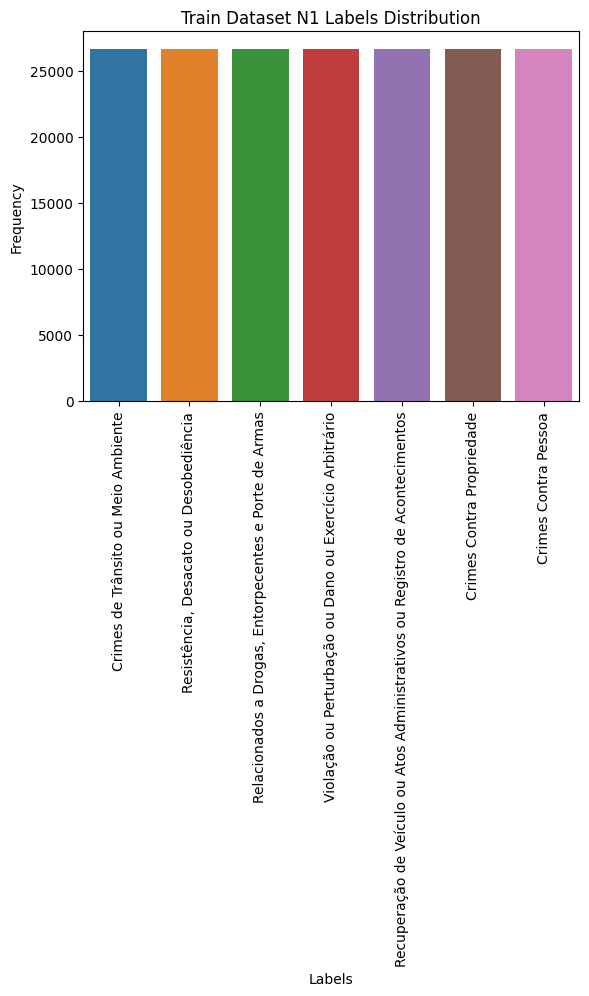

In [20]:
n1_count = data['N1'].value_counts().reset_index()
n1_count.columns = ['Labels', 'Frequency']
sns.barplot(data=n1_count, x='Labels', y='Frequency', hue='Labels')
plt.xticks(rotation=90)
plt.title("Train Dataset N1 Labels Distribution")
plt.show()

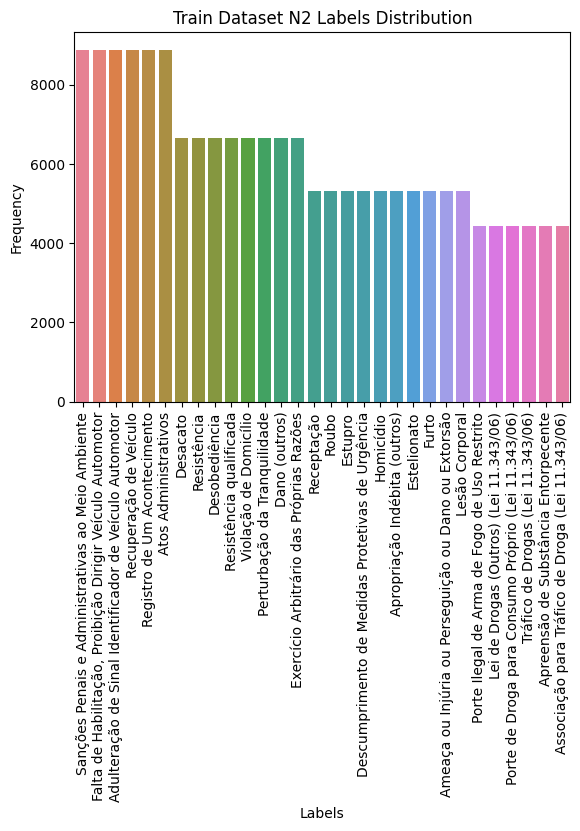

In [21]:
n1_count = data['N2'].value_counts().reset_index()
n1_count.columns = ['Labels', 'Frequency']
sns.barplot(data=n1_count, x='Labels', y='Frequency', hue='Labels')
plt.xticks(rotation=90)
plt.title("Train Dataset N2 Labels Distribution")
plt.show()

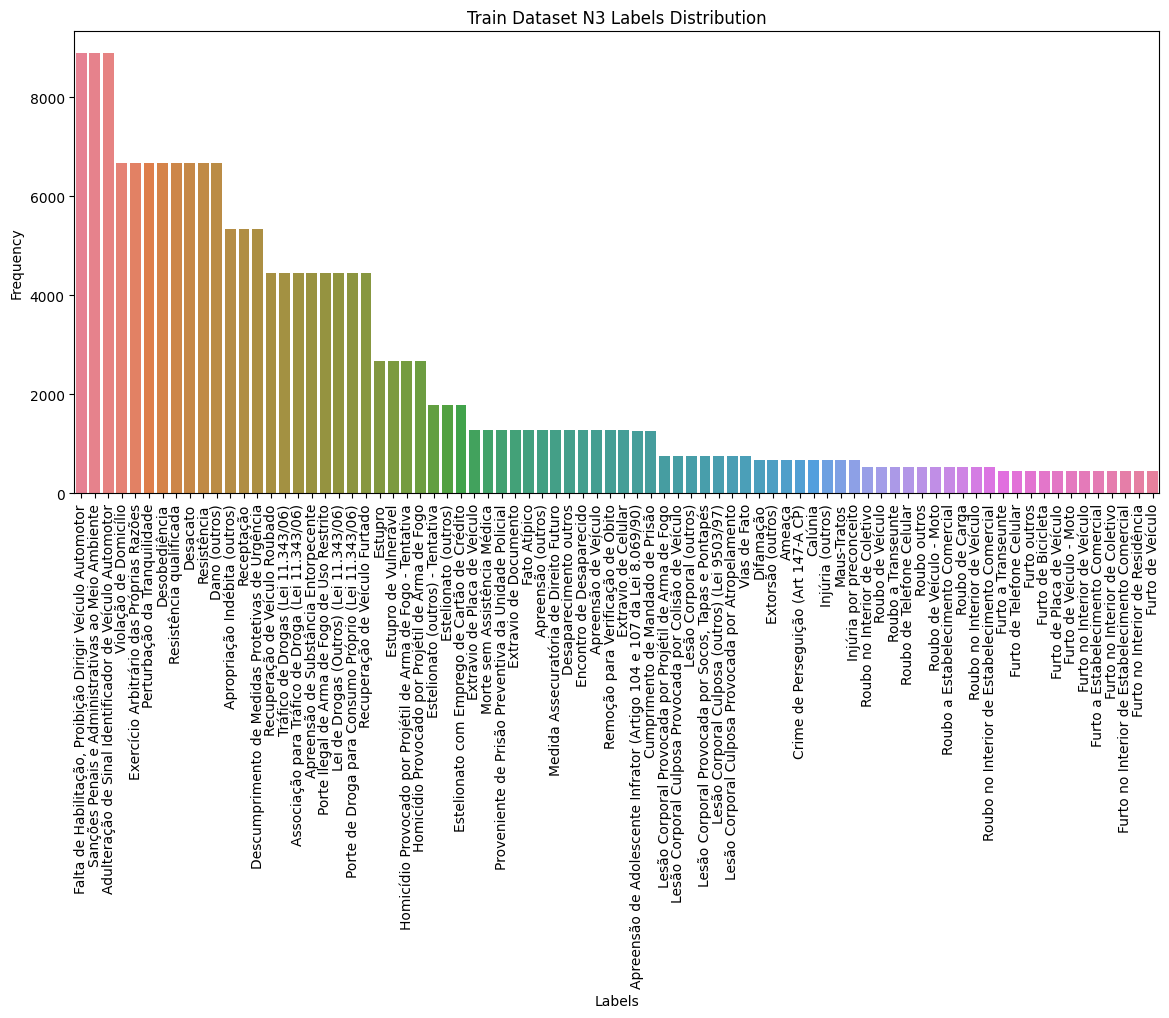

In [25]:
plt.figure(figsize=(14, 6))
n1_count = data['N3'].value_counts().reset_index()
n1_count.columns = ['Labels', 'Frequency']
sns.barplot(data=n1_count, x='Labels', y='Frequency', hue='Labels')
plt.xticks(rotation=90)
plt.title("Train Dataset N3 Labels Distribution")
plt.show()

# Statistical Tests

In [26]:
parallel = pd.read_csv("./parallel_classification_report.csv", sep=";")
parallel.head()

,class,H_precision,H_recall,H_f1-score,NH_precision,NH_recall,NH_f1-score,support
0,Adulteração de Sinal Identificador de Veículo ...,0.45014,0.81393,0.57968,0.38378,0.80656,0.52008,1220
1,Ameaça,0.71161,0.19272,0.30330,0.78495,0.13640,0.23241,18732
2,Apreensão (outros),0.72050,0.25282,0.37429,0.76954,0.27897,0.40949,2753
3,Apreensão de Adolescente Infrator (Artigo 104 ...,0.74962,0.92336,0.82747,0.71902,0.93271,0.81204,535
4,Apreensão de Substância Entorpecente,0.34086,0.80731,0.47933,0.34476,0.79184,0.48038,711


In [42]:
def calc_and_print(metric):
    hierarchical = 'H_' + metric
    non_hierarchical = 'NH_' + metric
    
    stat, p = wilcoxon(parallel[hierarchical], parallel[non_hierarchical])

    print(f"{metric.capitalize()}:\n\tstat: {stat}\n\tp-value: {format(p, 'f')}")

In [45]:
calc_and_print('precision')
calc_and_print('recall')
calc_and_print('f1-score')

Precision:
	stat: 1620.0
	p-value: 1.000000
Recall:
	stat: 659.0
	p-value: 0.000007
F1-score:
	stat: 699.5
	p-value: 0.000010


In [36]:
stat, p = wilcoxon(parallel['H_precision'], parallel['NH_f1-score'])
print(f"F1-Score:\n\tstat: {stat}\n\tp-value: {format(p, 'f')}")

stat, p = wilcoxon(parallel['H_f1-score'], parallel['NH_f1-score'])
print(f"F1-Score:\n\tstat: {stat}\n\tp-value: {format(p, 'f')}")

stat, p = wilcoxon(parallel['H_f1-score'], parallel['NH_f1-score'])
print(f"F1-Score:\n\tstat: {stat}\n\tp-value: {format(p, 'f')}")

F1-Score:
	stat: 699.5
	p-value: 0.000010


# Tree View

In [3]:
dm = pd.read_csv("../../../CE1/Datasets/04_DomainHierarchy.csv")
dm.head()

,N1,N2,N3
0,Crimes Contra Propriedade,Estelionato,Estelionato (outros)
1,Crimes Contra Propriedade,Estelionato,Estelionato (outros) - Tentativa
2,Crimes Contra Propriedade,Estelionato,Estelionato com Emprego de Cartão de Crédito
3,Crimes Contra Propriedade,Roubo,Roubo a Transeunte
4,Crimes Contra Propriedade,Roubo,Roubo de Veículo


In [16]:
# M1
print(f"M1 - Root: {dm['N1'].unique()}")

M1 - Root: ['Crimes Contra Propriedade' 'Crimes Contra Pessoa'
 'Crimes de Trânsito ou Meio Ambiente'
 'Recuperação de Veículo ou Atos Administrativos ou Registro de Acontecimentos'
 'Relacionados a Drogas, Entorpecentes e Porte de Armas'
 'Resistência, Desacato ou Desobediência'
 'Violação ou Perturbação ou Dano ou Exercício Arbitrário']


In [14]:
count = 2
for i in dm['N1'].unique():
    print(f"M{count} - {i}: {dm[dm['N1'] == i]['N2'].unique()}\n")
    count += 1

M2 - Crimes Contra Propriedade: ['Estelionato' 'Roubo' 'Furto' 'Receptação'
 'Apropriação Indébita (outros)']

M3 - Crimes Contra Pessoa: ['Homicídio' 'Estupro' 'Lesão Corporal'
 'Ameaça ou Injúria ou Perseguição ou Dano ou Extorsão'
 'Descumprimento de Medidas Protetivas de Urgência']

M4 - Crimes de Trânsito ou Meio Ambiente: ['Adulteração de Sinal Identificador de Veículo Automotor'
 'Falta de Habilitação, Proibição Dirigir Veículo Automotor'
 'Sanções Penais e Administrativas ao Meio Ambiente']

M5 - Recuperação de Veículo ou Atos Administrativos ou Registro de Acontecimentos: ['Recuperação de Veículo' 'Atos Administrativos'
 'Registro de Um Acontecimento']

M6 - Relacionados a Drogas, Entorpecentes e Porte de Armas: ['Tráfico de Drogas (Lei 11.343/06)'
 'Porte de Droga para Consumo Próprio (Lei 11.343/06)'
 'Associação para Tráfico de Droga (Lei 11.343/06)'
 'Apreensão de Substância Entorpecente'
 'Lei de Drogas (Outros) (Lei 11.343/06)'
 'Porte Ilegal de Arma de Fogo de Uso Restr

In [20]:
count = 9
for i in dm['N2'].unique():
    lista = dm[dm['N2'] == i]['N3'].unique()
    if len(lista) > 1:
        print(f"M{count} - {i}: {lista}\n")
        count += 1

M9 - Estelionato: ['Estelionato (outros)' 'Estelionato (outros) - Tentativa'
 'Estelionato com Emprego de Cartão de Crédito']

M10 - Roubo: ['Roubo a Transeunte' 'Roubo de Veículo' 'Roubo outros'
 'Roubo de Telefone Celular' 'Roubo no Interior de Coletivo'
 'Roubo de Veículo - Moto' 'Roubo no Interior de Veículo' 'Roubo de Carga'
 'Roubo a Estabelecimento Comercial'
 'Roubo no Interior de Estabelecimento Comercial']

M11 - Furto: ['Furto outros' 'Furto de Telefone Celular' 'Furto a Transeunte'
 'Furto de Veículo' 'Furto no Interior de Residência'
 'Furto no Interior de Estabelecimento Comercial'
 'Furto no Interior de Coletivo' 'Furto a Estabelecimento Comercial'
 'Furto no Interior de Veículo' 'Furto de Veículo - Moto'
 'Furto de Bicicleta' 'Furto de Placa de Veículo']

M12 - Homicídio: ['Homicídio Provocado por Projétil de Arma de Fogo'
 'Homicídio Provocado por Projétil de Arma de Fogo - Tentativa']

M13 - Estupro: ['Estupro' 'Estupro de Vulnerável']

M14 - Lesão Corporal: ['Lesão C